| Name | Bryan Shin G. Dumaguete |
|---|---|
| ID Number | 2023100305 |
| Section | BSCpE_2A_STEM |

# Coding Assignment 1: Exploratory Data Analysis for Neural Networks

## Objectives
By the end of this activity, you will be able to:
1. Load and inspect a real-world dataset.
2. Apply the full range of EDA visualization techniques covered in class.
3. Interpret each plot in the context of preparing data for a neural network.
4. Justify preprocessing decisions (scaling, encoding, outlier handling) based on visual evidence.

## Dataset
**Dataset:** Pima Indians Diabetes Dataset


**Description:** 768 patient records with 8 numeric medical predictor features and a binary target (`Outcome`: 1 = diabetic, 0 = non-diabetic). It is commonly used to build a neural network binary classifier, and it contains realistic data-quality issues (disguised missing values, skewed distributions, outliers) that make it excellent for EDA practice.

**Direct download (already wired into the loader cell below):**
`https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv`

Run the cell below first — do not change it.

Write your program in each code cell as needed. Write your observations and explanations in each markdown cell (create one if none is provided).

<font color="red">Create a copy of this notebook and edit that copy. Do not make any alterations in this notebook. Anyone who will be caught editing this notebook will automatically marked zero.</font>

In [126]:
#Dataset Loader (please do not modify this part)
import pandas as pd

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=columns)

# NOTE: In this dataset, 0 is used as a placeholder for missing values in several medical columns. Part of your task is to identify and handle this.
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [127]:
#The following libraries are used for data analysis and visualization, as well as for building and evaluating machine learning models.
# If you need more packages, you can install them using pip.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

try:
    import missingno as msno
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "missingno", "--quiet"])
    import missingno as msno

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


---
## Task 1 — Data Overview (15 pts)
Display the shape, data types, and summary statistics of the dataset. Write a 2–3 sentence observation about what you notice (e.g., ranges, suspicious zero values).


TASK1 ---SHAPE

In [128]:
print("Shape of the Dataset:") 
print(df.shape)

Shape of the Dataset:
(768, 9)


TASK1 ---DATATYPES

In [129]:
print("Data Types of the Dataset:")
print(df.dtypes)

Data Types of the Dataset:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


TASK1 ---SUMMARY

In [130]:
print("Summary Statistics of the Dataset:")
df.describe().T

Summary Statistics of the Dataset:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Observation:**
The dataset has 768 rows and 9 numeric columns. Some columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI have zero values. These zero values may represent missing data because zero is not a realistic value for these medical measurements.

## Task 2 — Missing Value Analysis (15 pts)
The columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use `0` to represent missing data, which is not medically possible. Replace these zeros with `NaN`, then produce:
- A **missingno matrix** plot
- A **missingno bar** plot
- A **heatmap** of missing values

Interpret the results: which columns have the most missing data?


TASK2 ---MISSINGVALUES

In [131]:
missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[missing_columns] = df[missing_columns].replace(0, np.nan)

print("Missing Values in the Dataset:")
print(df.isnull().sum().to_string())

Missing Values in the Dataset:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0


TASK2 ---MATRIX

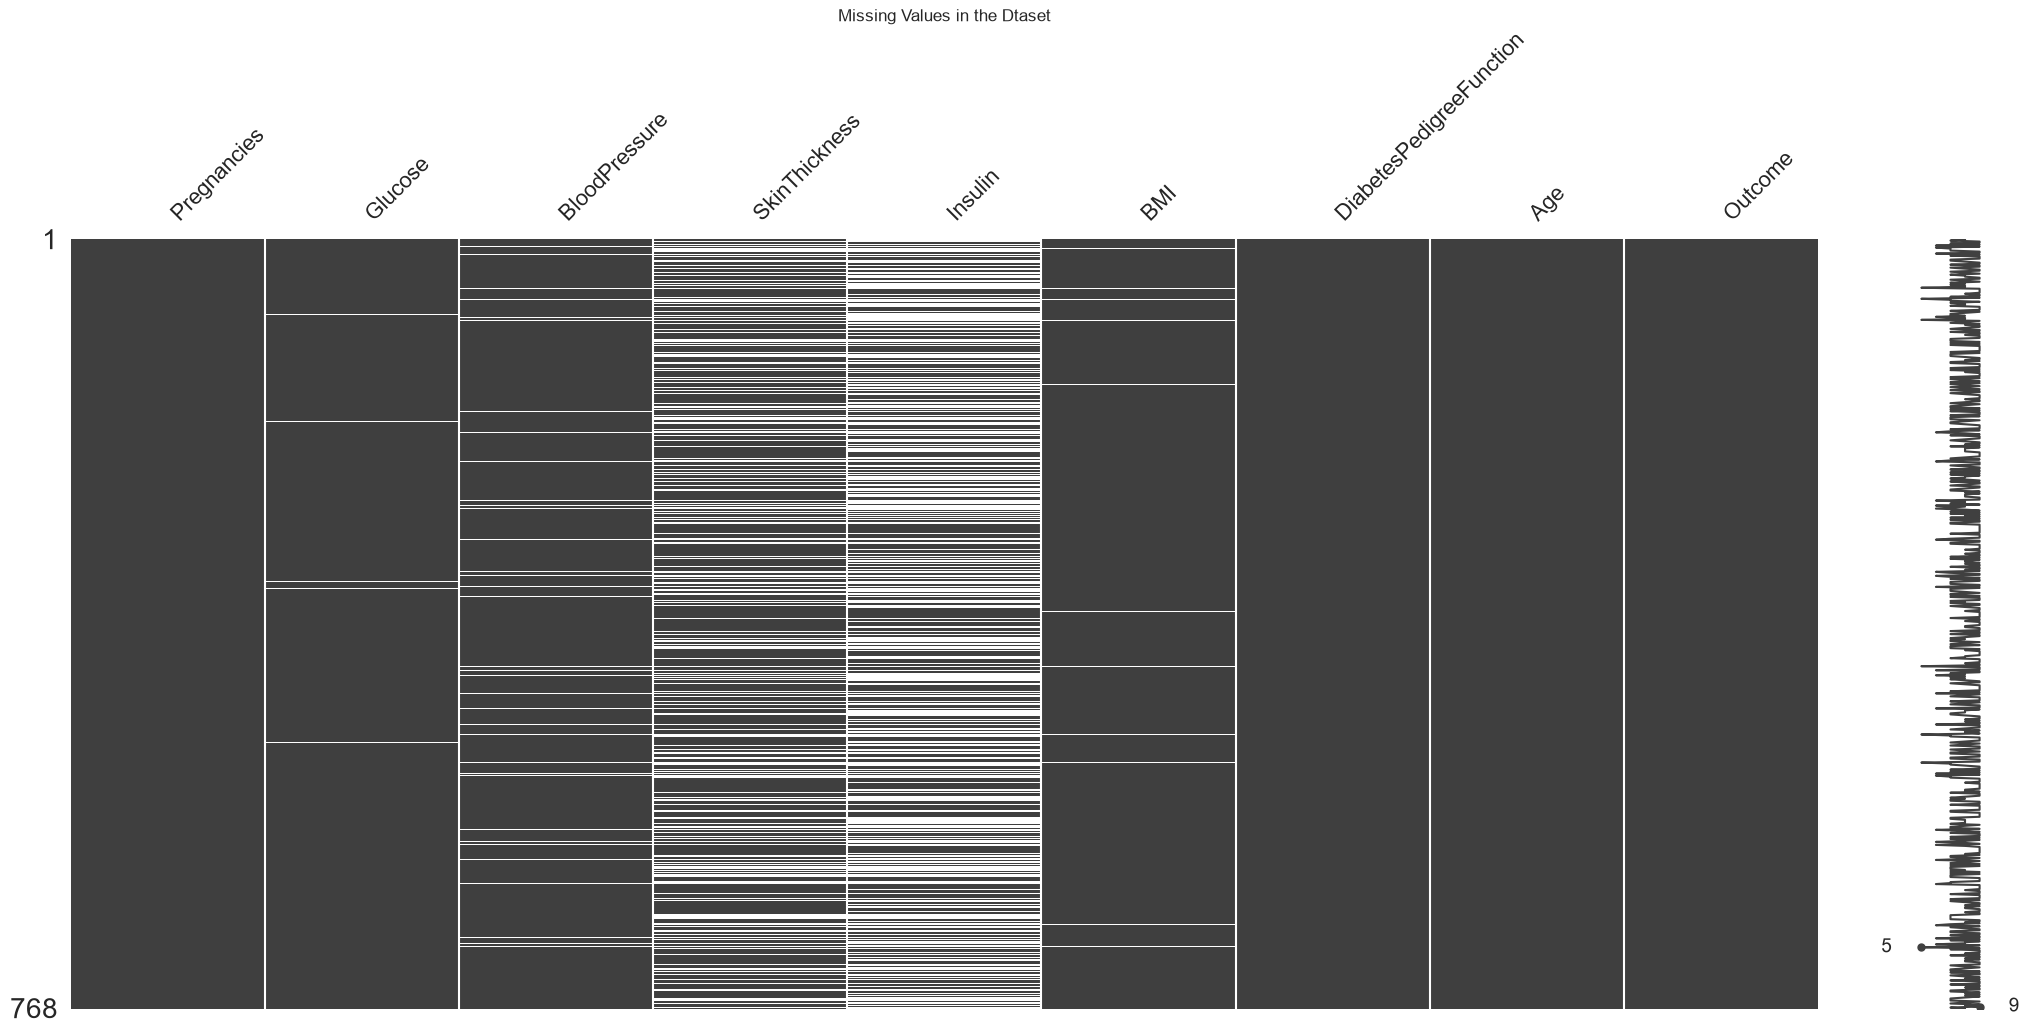

In [132]:
msno.matrix(df)

plt.title("Missing Values in the Dtaset")
plt.show()

TASK2 ---BARGRAPH

Bar chart of Missing Values in the Dataset


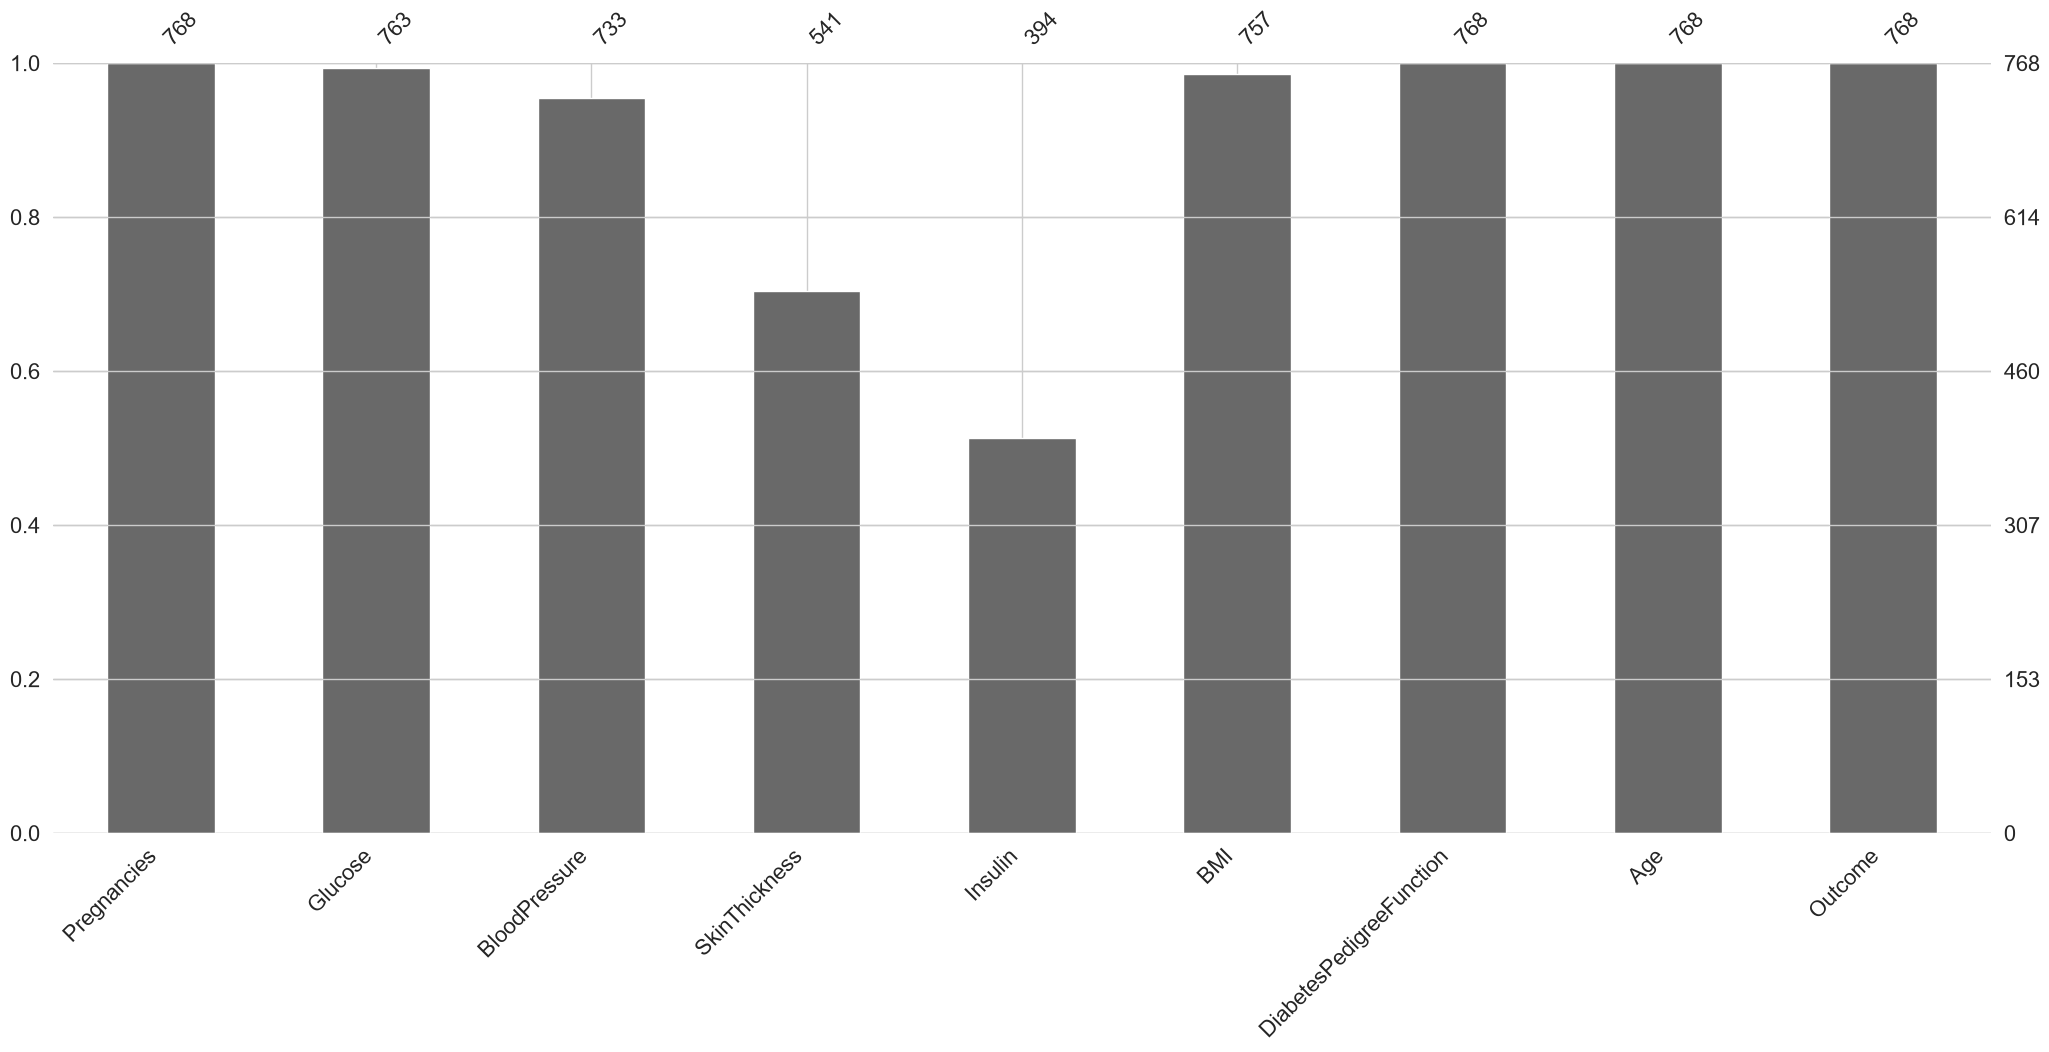

In [133]:
msno.bar(df)

print("Bar chart of Missing Values in the Dataset")
plt.show()

TASK2 ---HEATMAP

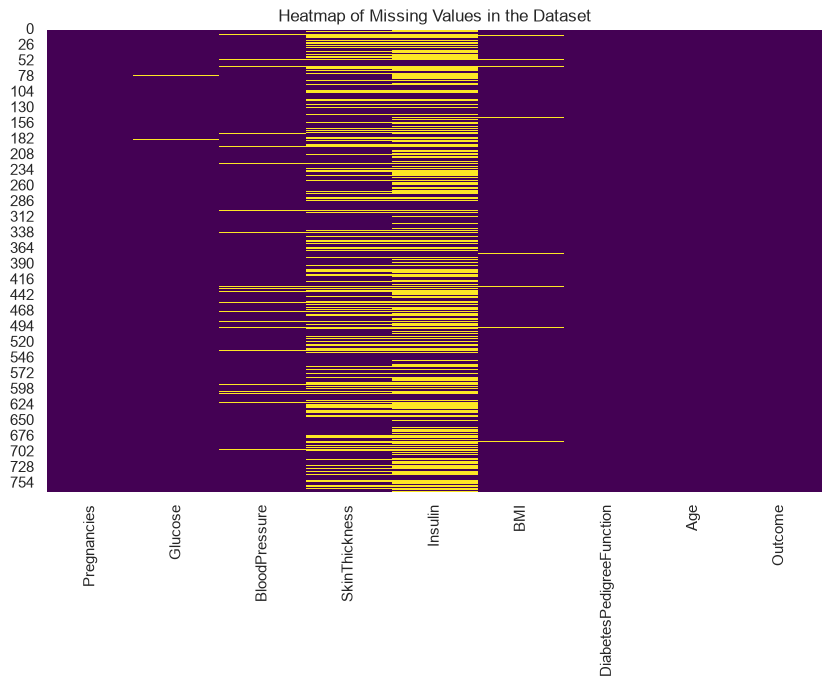

In [134]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values in the Dataset")
plt.show()

## Task 3 — Univariate Analysis (25 pts)
For at least 3 numeric features, produce:
- **Histogram**
- **KDE plot**
- **Box (whisker) plot**
- **Violin plot**
- **Q-Q plot**

Identify which features are skewed and which contain outliers.


TASK 3 ---HISTOGRAM

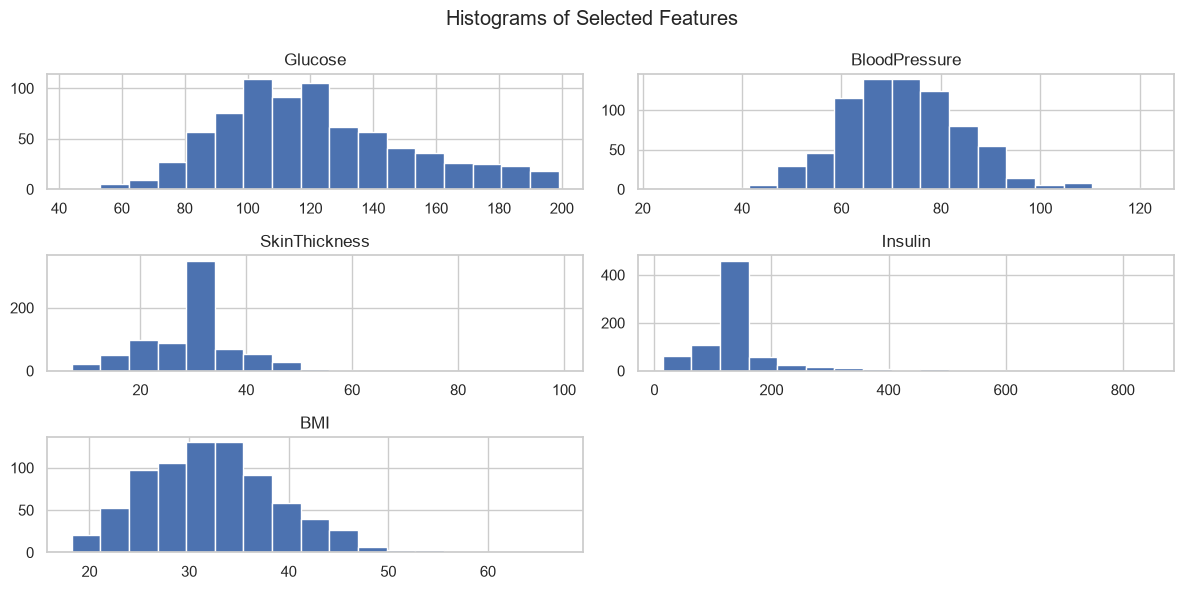

In [135]:

features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[features] = df[features].fillna(df[features].mean())

df[features].hist(bins=17, figsize=(12, 6))
plt.suptitle("Histograms of Selected Features")
plt.tight_layout()
plt.show()

TASK 3 ---KDEPLOT

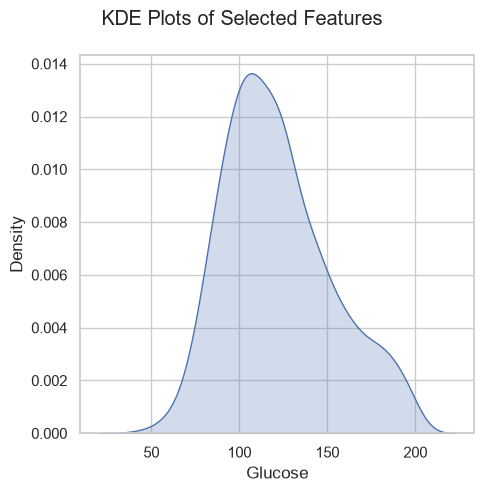

In [136]:
plt.figure(figsize=(5 , 5))
sns.kdeplot(df["Glucose"], fill=True)
plt.suptitle("KDE Plots of Selected Features")
plt.tight_layout()
plt.show()

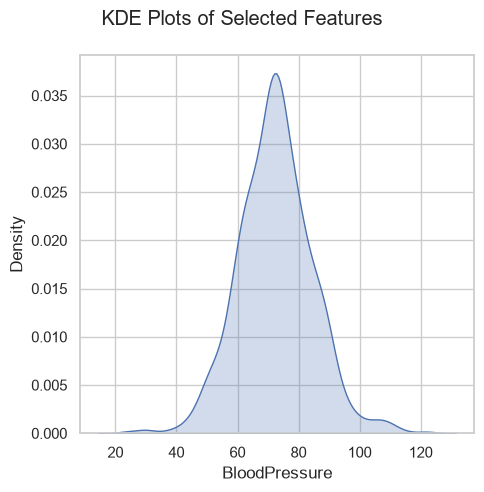

In [137]:
plt.figure(figsize=(5 , 5))
sns.kdeplot(df["BloodPressure"], fill=True)
plt.suptitle("KDE Plots of Selected Features")
plt.tight_layout()
plt.show()

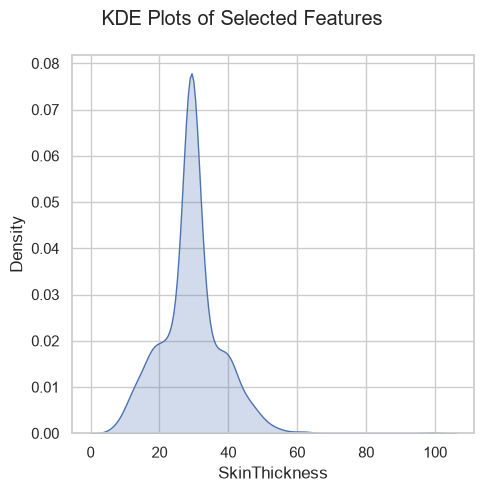

In [138]:
plt.figure(figsize=(5 , 5))
sns.kdeplot(df["SkinThickness"], fill=True)
plt.suptitle("KDE Plots of Selected Features")
plt.tight_layout()
plt.show()

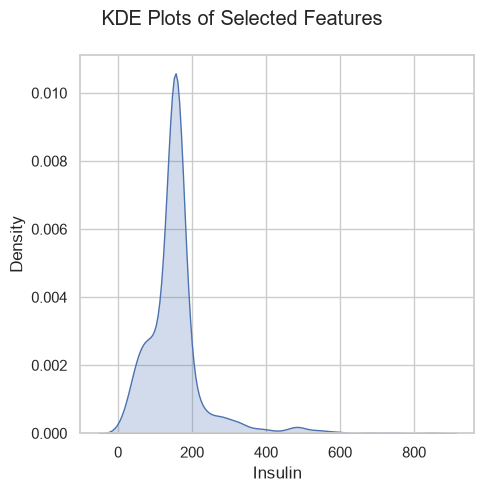

In [139]:
plt.figure(figsize=(5 , 5))
sns.kdeplot(df["Insulin"], fill=True)
plt.suptitle("KDE Plots of Selected Features")
plt.tight_layout()
plt.show()

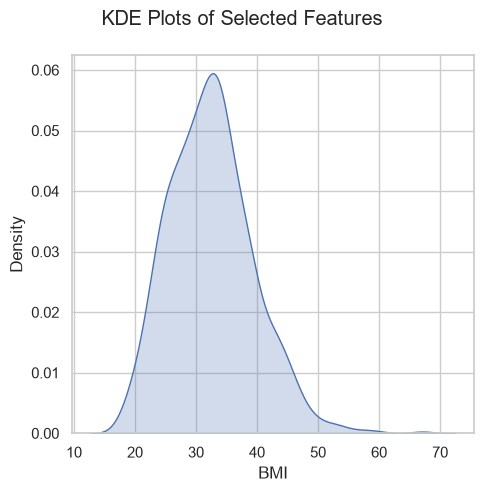

In [140]:
plt.figure(figsize=(5 , 5))
sns.kdeplot(df["BMI"], fill=True)
plt.suptitle("KDE Plots of Selected Features")
plt.tight_layout()
plt.show()

TASK3 ---BOXPLOT

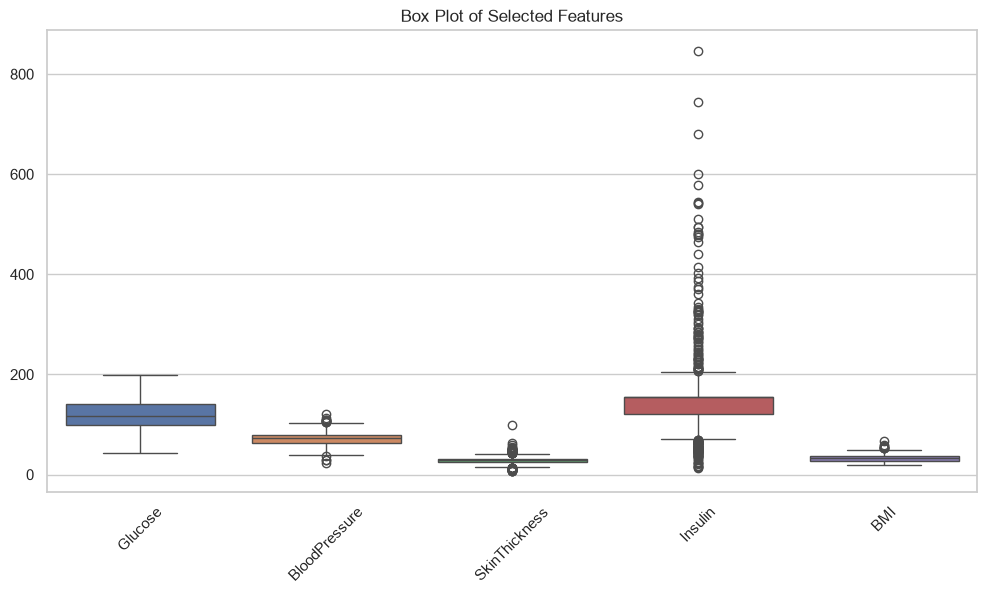

In [141]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Box Plot of Selected Features")
plt.show()

TASK3 ---VIOLINPLOT

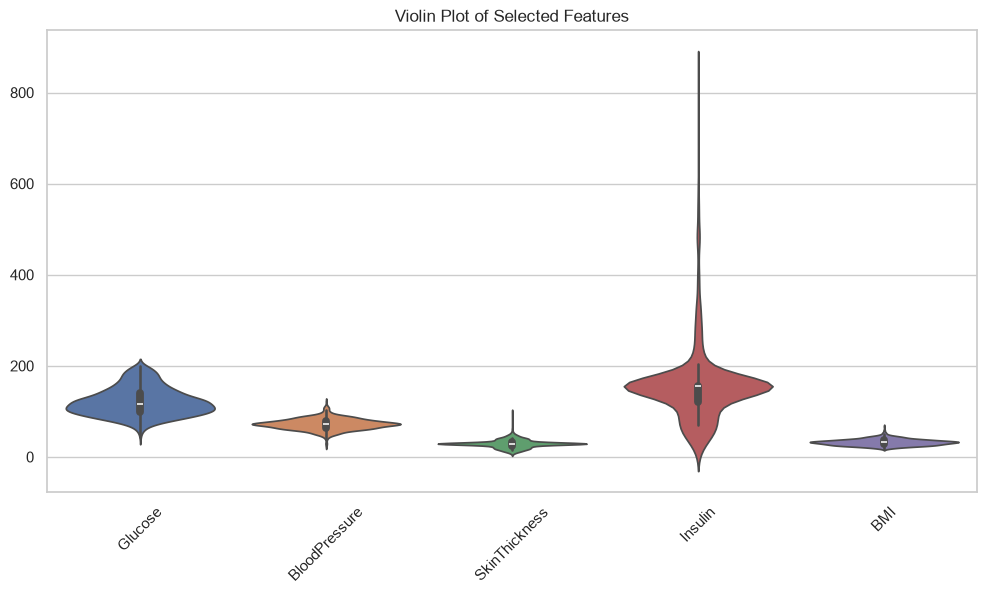

In [142]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Violin Plot of Selected Features")
plt.show()  

TASK3 ---Q-QPLOT

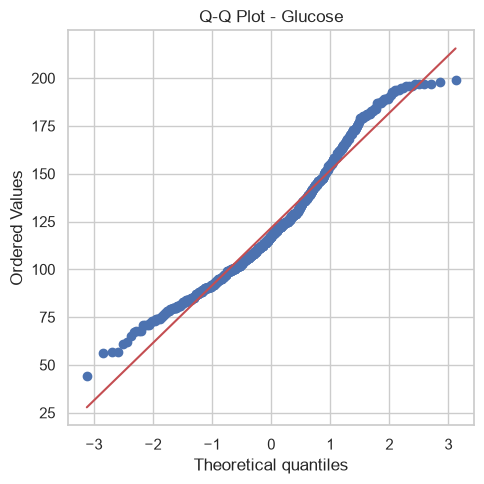

In [143]:
plt.figure(figsize=(5,5))
stats.probplot(df["Glucose"],dist="norm", plot=plt)
plt.title("Q-Q Plot - Glucose")
plt.tight_layout()
plt.show()


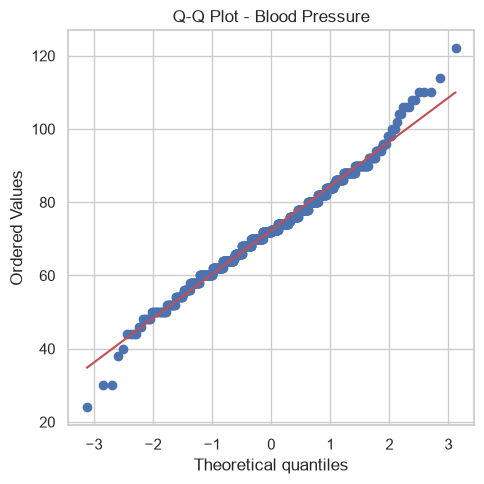

In [144]:
plt.figure(figsize=(5,5))
stats.probplot(df["BloodPressure"],dist="norm", plot=plt)
plt.title("Q-Q Plot - Blood Pressure")
plt.tight_layout()
plt.show()

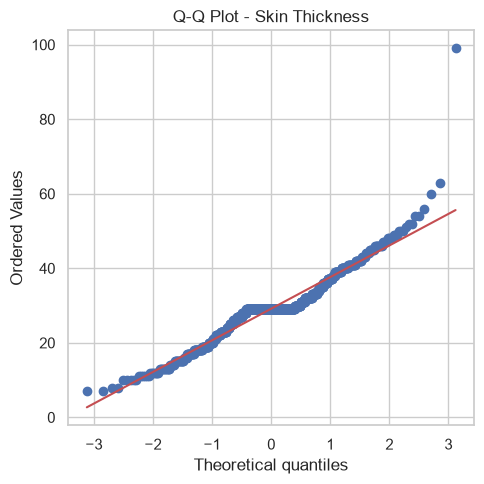

In [145]:
plt.figure(figsize=(5,5))
stats.probplot(df["SkinThickness"],dist="norm", plot=plt)
plt.title("Q-Q Plot - Skin Thickness")
plt.tight_layout()
plt.show()

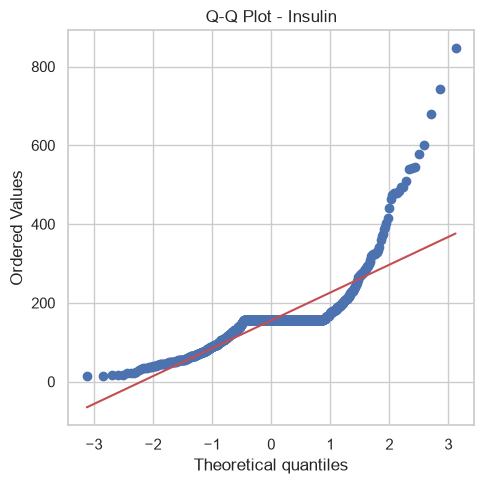

In [146]:
plt.figure(figsize=(5,5))
stats.probplot(df["Insulin"],dist="norm", plot=plt)
plt.title("Q-Q Plot - Insulin")
plt.tight_layout()
plt.show()

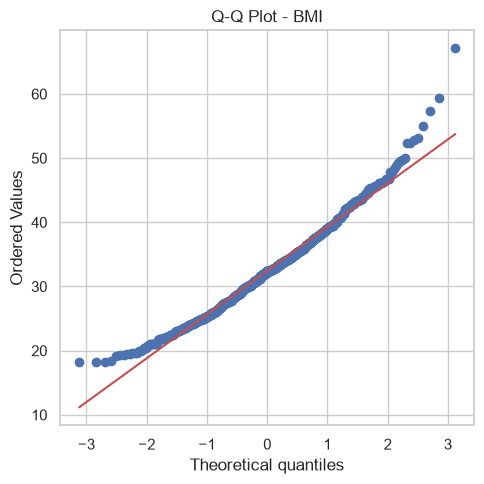

In [147]:
plt.figure(figsize=(5,5))
stats.probplot(df["BMI"],dist="norm", plot=plt)
plt.title("Q-Q Plot - BMI")
plt.tight_layout()
plt.show()

OBSERVATION: 

## Task 4 — Bivariate Analysis (15 pts)
Produce:
- A **scatter plot** of `Glucose` vs `Age`, colored by `Outcome`
- A **joint plot** of `BMI` vs `Insulin`
- A **regression plot** of `Glucose` vs `Outcome`

Explain what relationship (if any) each plot reveals.


TASK4 ---SCATTERPLOT

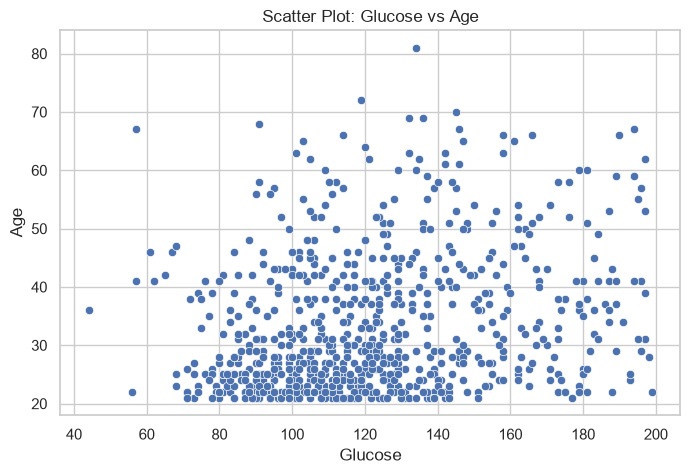

In [148]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Glucose", y="Age")
plt.title("Scatter Plot: Glucose vs Age")
plt.show()


TASK4 ---JOINTPLOT

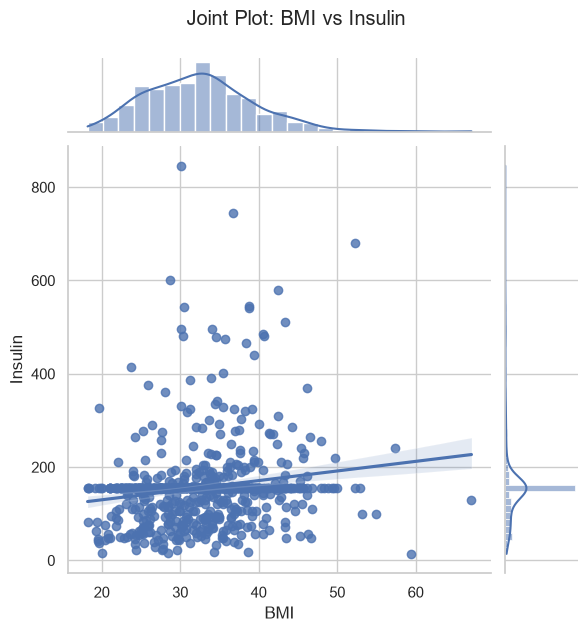

In [149]:
sns.jointplot(data=df, x="BMI", y="Insulin", kind="reg", height=6)
plt.suptitle("Joint Plot: BMI vs Insulin", y=1.05)
plt.show()

TASK4 ---REGRESSIONPLOT

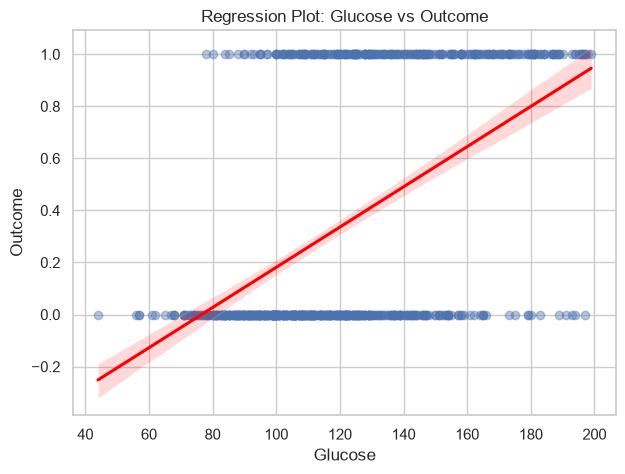

In [150]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=df, 
    x="Glucose", 
    y="Outcome", 
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Regression Plot: Glucose vs Outcome")
plt.show()


## Task 5 — Categorical Visualizations (10 pts)
Produce:
- A **count plot** of the `Outcome` target variable (check for class imbalance — this matters a lot for NN training!)
- A **pie chart** showing the proportion of diabetic vs non-diabetic patients

Comment on whether the classes are balanced and what that means for training a neural network.


TASK5 ---COUNTPLOT

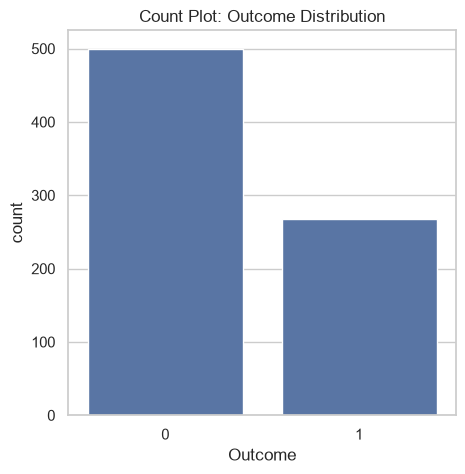

In [154]:
# Bar / count plot - target class distribution (important before NN training for class imbalance)
plt.figure(figsize=(5,5))
sns.countplot(data=df, x="Outcome")
plt.title("Count Plot: Outcome Distribution")
plt.show()

TASK5 ---PIECHART

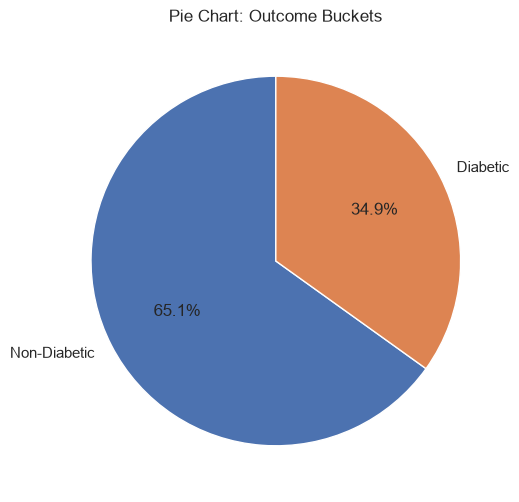

In [165]:
bins = [-0.5, 0.5, 1.5]
labels = ["Non-Diabetic", "Diabetic"]
df["outcome_bucket"] = pd.cut(df["Outcome"], bins=bins, labels=labels)

plt.figure(figsize=(6,6))
df["outcome_bucket"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart: Outcome Buckets")
plt.ylabel("")
plt.show()


## Task 6 — Multivariate Analysis (20 pts)
Produce:
- A **pair plot** of at least 5 features, colored by `Outcome`
- A **facet grid** showing the distribution of `Glucose` split by `Outcome`
- A **correlation heatmap** of all numeric features
- A **3D scatter plot** using any 3 features, colored by `Outcome`

Identify the two features most correlated with `Outcome`.


In [152]:
#Task 6



---
## Submission Checklist
- All 6 tasks completed with working code and output visible
- Each plot has a title and axis labels
- Written interpretation included under each task
- Notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)

## Grading Rubric (100 pts total)
| Task | Points |
|---|---|
| 1. Data Overview | 15 |
| 2. Missing Value Analysis | 15 |
| 3. Univariate Analysis | 25 |
| 4. Bivariate Analysis | 15 |
| 5. Categorical Visualizations | 10 |
| 6. Multivariate Analysis | 20 |